# Transformer V9 (频域滤波+DAE) — 推理打分

加载 `transformer_model.json`，在测试区间上推理。训练逻辑在 `transformer_train_v9.py`。

V9 与 V7 推理接口相同: `model(x, return_recon=False)` → 只返回预测值。

---

## 非线性因子变换（对抗 BARRA 线性回归中性化）

平台会在因子评估前做 **"风格剔除(取残差)"**：对原始因子值与 BARRA 风格因子做 **线性回归 (OLS)**，
取残差作为新因子值。如果原始因子与 BARRA 因子之间存在**线性关系**，OLS 会解释掉大部分方差，
残差中残余的 alpha 信息大幅减少。

### 解法

在返回因子值前，对原始 score 做**截面非线性变换**。变换后的 score 与 BARRA 因子呈**非线性关系**，
OLS 能解释的方差大幅减少 → 残差中保留更多 alpha。

所有变换均保持**截面排序不变**（即 alpha 方向一致），仅改变 score 的**分布形态**。

### 可选方法

| 方法 | 原理 | 推荐场景 |
|------|------|----------|
| `rank_normal` | 截面排名 → 标准正态分位数 | **最彻底的非线性化**，推荐首选 |
| `rank_uniform` | 截面排名 → [0,1] 均匀分布 | 类似 rank_normal，但分布不同 |
| `tanh` | tanh(α × zscore)，平滑压缩 | 较温和，保留部分量级信息 |
| `power` | sign(z) × |z|^p | p<1 压缩尾部，p>1 放大尾部 |
| `none` | 不做变换 | 对照基线 |

In [1]:
import os, numpy as np, pandas as pd, dai, torch, structlog
from transformer_train_v9_memopt import (
    MODEL_PATH, BATCH, FEATURE_COLS, FEATURE_FLAGS, SPECTRAL_FILTER,
    StockTransformerV9, build_dataset, pool, train_and_save, load_model,
)
logger = structlog.get_logger()

In [2]:
# ============================================================
# 非线性因子变换：对抗平台 BARRA 线性回归中性化
# ============================================================
# 平台会对因子做"风格剔除(取残差)"：factor ~ BARRA风格因子 (OLS) → 取残差。
# 若 score 与 BARRA 因子之间是线性关系，OLS 残差中 alpha 信息大幅损失。
#
# 解法：对原始 score 做截面非线性变换 → 变换后的 score 与 BARRA 因子
# 呈非线性关系 → OLS 解释方差更少 → 残差保留更多 alpha。
#
# 所有变换均保持截面排序不变（alpha 方向一致），仅改变分布形态。

TRANSFORM_METHOD = "rank_normal"  # rank_normal | rank_uniform | tanh | power | none

# —— tanh / power 的参数（仅对应方法生效）——
TRANSFORM_ALPHA = 3.0   # tanh: 越大非线性越强 (推荐 2.0~5.0)
TRANSFORM_POWER = 0.5   # power: <1 压缩极端值, >1 放大极端值


def _norm_ppf(p):
    """标准正态分位数函数（Acklam 算法，不依赖 scipy）。

    相对误差 < 1.15e-9，用于 rank_normal 变换。
    """
    p = np.asarray(p, np.float64)

    # 中段系数
    a1, a2, a3 = -39.6968302866538,  220.9460984245205, -275.9285104469687
    a4, a5, a6 =  138.3577518672690, -30.66479806614716, 2.506628277459239
    b1, b2, b3 = -54.47609879822406,  161.5858368580409, -155.6989798598866
    b4, b5     =  66.80131188771972, -13.28068155288572
    # 尾段系数
    c1, c2, c3 = -7.784894002430293e-03, -0.3223964580411365, -2.400758277161838
    c4, c5, c6 = -2.549732539343734,       4.374664141464968,   2.938163982698783
    d1, d2     =  7.784695709041462e-03,   0.3224671290700398
    d3, d4     =  2.445134137142996,       3.754408661907416

    result = np.full_like(p, np.nan, dtype=np.float64)

    # 下尾 p < 0.02425
    low = (p > 0.0) & (p < 0.02425)
    if low.any():
        q = np.sqrt(-2.0 * np.log(p[low]))
        num = ((((c1 * q + c2) * q + c3) * q + c4) * q + c5) * q + c6
        den = ((( d1 * q + d2) * q + d3) * q + d4) * q + 1.0
        result[low] = num / den

    # 中段 0.02425 ≤ p ≤ 0.97575
    high = (p >= 0.02425) & (p <= 0.97575)
    if high.any():
        q = p[high] - 0.5
        r = q * q
        num = ((((a1 * r + a2) * r + a3) * r + a4) * r + a5) * r + a6
        den = ((((b1 * r + b2) * r + b3) * r + b4) * r + b5) * r + 1.0
        result[high] = q * num / den

    # 上尾 p > 0.97575
    upper = (p > 0.97575) & (p < 1.0)
    if upper.any():
        q = np.sqrt(-2.0 * np.log(1.0 - p[upper]))
        num = ((((c1 * q + c2) * q + c3) * q + c4) * q + c5) * q + c6
        den = ((( d1 * q + d2) * q + d3) * q + d4) * q + 1.0
        result[upper] = -num / den

    return result


def _safe_zscore(x_arr):
    """安全 z-score，返回与输入等长的 numpy 数组。"""
    x_arr = np.asarray(x_arr, np.float64)
    finite = np.isfinite(x_arr)
    vals = x_arr[finite]
    if len(vals) < 2:
        return np.zeros(len(x_arr), dtype=np.float64)
    mean, std = np.mean(vals), np.std(vals)
    if std < 1e-12:
        return np.zeros(len(x_arr), dtype=np.float64)
    out = np.zeros(len(x_arr), dtype=np.float64)
    out[finite] = (x_arr[finite] - mean) / std
    return out


def _rank_to_normal(series):
    """截面排名 → 标准正态分位数 (Van der Waerden scores)。"""
    n = len(series)
    if n < 2:
        return pd.Series(np.zeros(n, dtype=np.float64), index=series.index)
    ranks = series.rank(method="average")
    # (0, 1) 内百分位，避免 0/1 产生 ±inf
    p = np.clip((ranks.values - 0.5) / n, 1e-15, 1.0 - 1e-15)
    scores = _norm_ppf(p)
    return pd.Series(scores, index=series.index)


def _power_transform(z, p):
    """sign(z) * |z|^p，保持符号的非线性缩放。"""
    z = np.asarray(z, np.float64)
    out = np.zeros_like(z, dtype=np.float64)
    pos = z > 0
    neg = z < 0
    out[pos] = z[pos] ** p
    out[neg] = -((-z[neg]) ** p)
    return out


def transform_factor(result_df, method="rank_normal", **kwargs):
    """对因子分数做截面非线性变换。

    Parameters
    ----------
    result_df : pd.DataFrame [date, instrument, score]
    method : str, 可选:
        - "rank_normal"  : 截面 percentile → 标准正态分位数 (推荐，最彻底的非线性化)
        - "rank_uniform" : 截面 percentile → [0, 1] 均匀分布
        - "tanh"         : tanh(alpha * zscore), 平滑非线性压缩
        - "power"        : sign(z) * |z|^p, p<1 压缩尾部, p>1 放大尾部
        - "none"         : 不做变换
    **kwargs : 方法参数 (tanh: alpha; power: p)

    Returns
    -------
    pd.DataFrame with transformed score column
    """
    df = result_df.copy()

    if method == "none":
        return df

    if method == "rank_normal":
        df["score"] = df.groupby("date", sort=False)["score"].transform(_rank_to_normal)

    elif method == "rank_uniform":
        df["score"] = df.groupby("date", sort=False)["score"].transform(
            lambda x: x.rank(pct=True)
        )

    elif method == "tanh":
        alpha = float(kwargs.get("alpha", 3.0))
        df["score"] = df.groupby("date", sort=False)["score"].transform(
            lambda x: np.tanh(alpha * _safe_zscore(x.values))
        )

    elif method == "power":
        p = float(kwargs.get("p", 0.5))
        df["score"] = df.groupby("date", sort=False)["score"].transform(
            lambda x: _power_transform(_safe_zscore(x.values), p)
        )

    else:
        raise ValueError(f"未知变换方法: {method}，可选: rank_normal, rank_uniform, tanh, power, none")

    return df


logger.info("非线性变换配置已加载", method=TRANSFORM_METHOD)

[2026-07-21 19:20:04] [info     ] 非线性变换配置已加载                     method=rank_normal


In [3]:
def main(datasources, start_date, end_date):
    table = datasources["bar1m"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"未找到 {MODEL_PATH}")

    ckpt = load_model(MODEL_PATH, map_location=device)
    stats = (np.asarray(ckpt["mean"], np.float32), np.asarray(ckpt["std"], np.float32))
    saved_flags = ckpt.get("feature_flags", FEATURE_FLAGS)
    use_sf = ckpt.get("spectral_filter", SPECTRAL_FILTER)
    model = StockTransformerV9(
        **ckpt["model_cfg"],
        session_aware=saved_flags.get("session_aware", False),
        use_preclose_gate=saved_flags.get("use_preclose_gate", False),
        use_tod_emb=saved_flags.get("use_tod_emb", True),
        use_prenorm=saved_flags.get("use_prenorm", True),
        use_spectral_filter=use_sf,
    ).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    logger.info("已加载 V9 模型", spectral_filter=use_sf)

    Xte, _, idx_df, _ = build_dataset(table, start_date, end_date, "infer", pool(start_date, end_date), stats)
    preds = []
    with torch.no_grad():
        for i in range(0, len(idx_df), BATCH):
            xb = torch.from_numpy(Xte[i:i+BATCH]).to(device)
            preds.append(model(xb, return_recon=False).cpu().numpy())
    preds = np.concatenate(preds).astype(np.float64)
    if ckpt.get("target_transform") == "log1p":
        preds = np.expm1(preds)
    idx_df["score"] = preds

    stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments", filters={"date": [start_date, end_date]}).df()
    result = (pd.merge(idx_df, stk, on=["date","instrument"], how="inner")
                .replace([np.inf,-np.inf], np.nan).dropna(subset=["score"])
                .drop_duplicates(["date","instrument"])[["date","instrument","score"]]
                .reset_index(drop=True))
    logger.info("分数构建完成", rows=len(result))

    # —— 非线性变换：对抗 BARRA 线性回归中性化 ——
    result = transform_factor(result, method=TRANSFORM_METHOD,
                              alpha=TRANSFORM_ALPHA, p=TRANSFORM_POWER)
    logger.info("非线性变换完成", method=TRANSFORM_METHOD, rows=len(result))

    return result

[2026-07-21 19:20:05] [info     ] 已加载 V9 模型                      spectral_filter=True
[2026-07-21 19:20:28] [info     ] 批次完成                           batch=1/9 batch_samples=36079 cum_samples=36079
[2026-07-21 19:20:40] [info     ] 批次完成                           batch=2/9 batch_samples=36162 cum_samples=72241
[2026-07-21 19:20:50] [info     ] 批次完成                           batch=3/9 batch_samples=36279 cum_samples=108520
[2026-07-21 19:21:02] [info     ] 批次完成                           batch=4/9 batch_samples=36240 cum_samples=144760
[2026-07-21 19:21:16] [info     ] 批次完成                           batch=5/9 batch_samples=35685 cum_samples=180445
[2026-07-21 19:21:28] [info     ] 批次完成                           batch=6/9 batch_samples=36258 cum_samples=216703
[2026-07-21 19:21:41] [info     ] 批次完成                           batch=7/9 batch_samples=36292 cum_samples=252995
[2026-07-21 19:21:53] [info     ] 批次完成                           batch=8/9 batch_samples=36265 cum_samples=289260
[202

时段,IC
2024-01-15~2024-02-08,-0.0003
2024-09-24~2024-10-08,0.0732

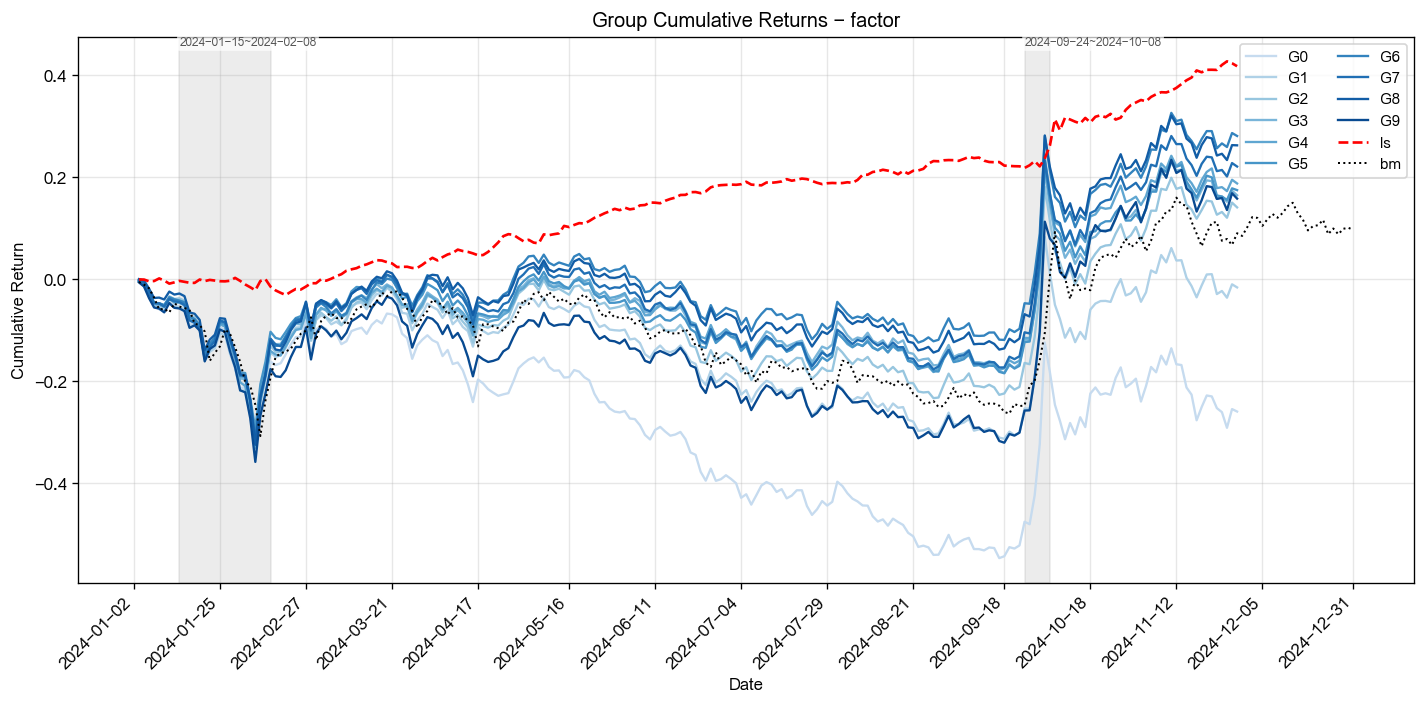
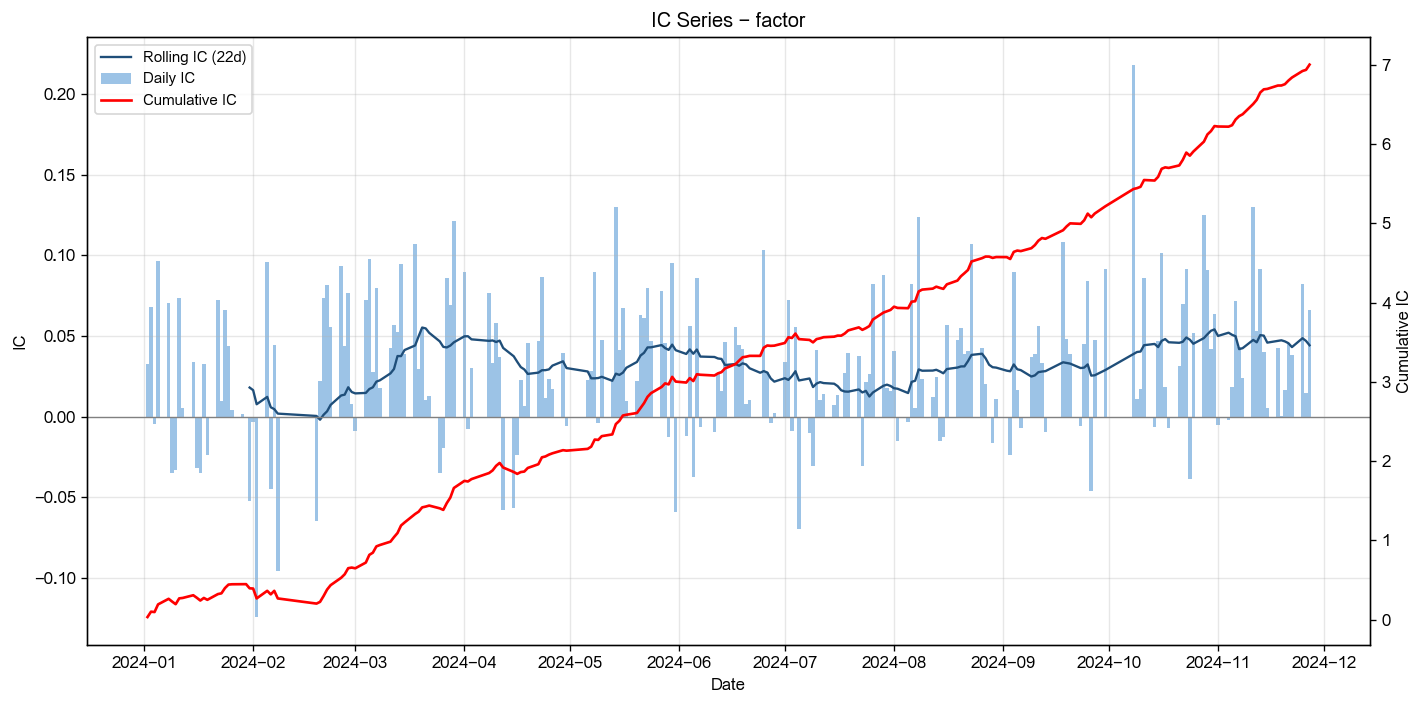
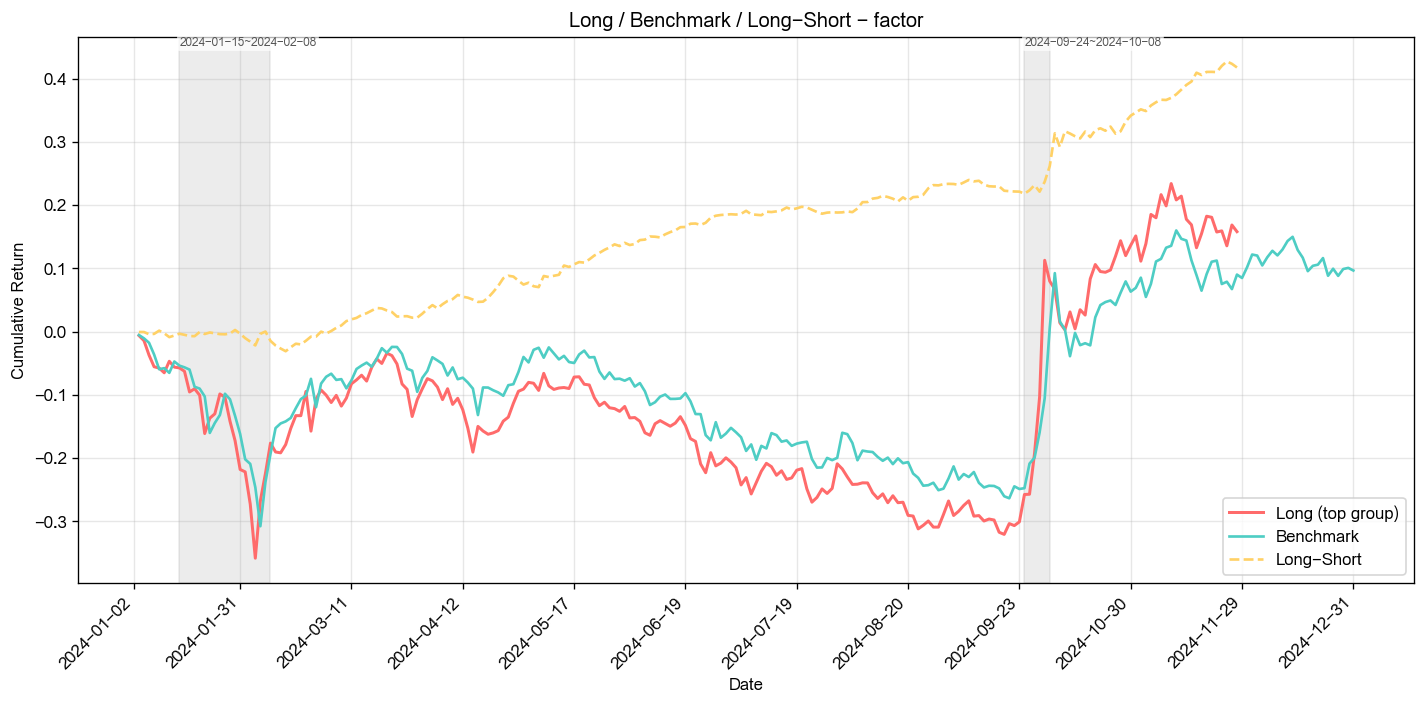
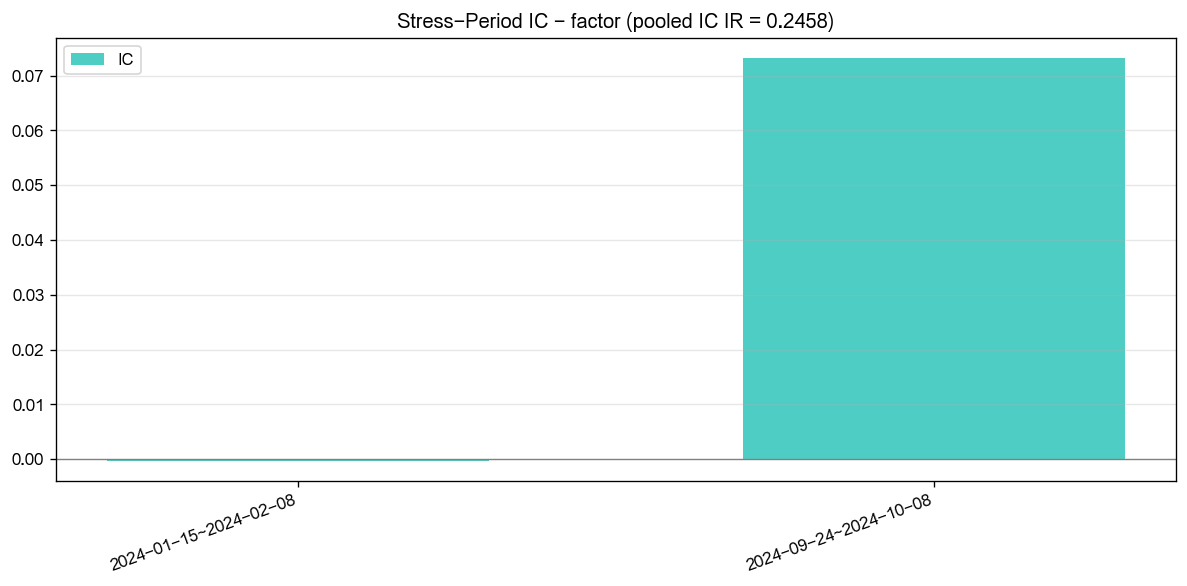
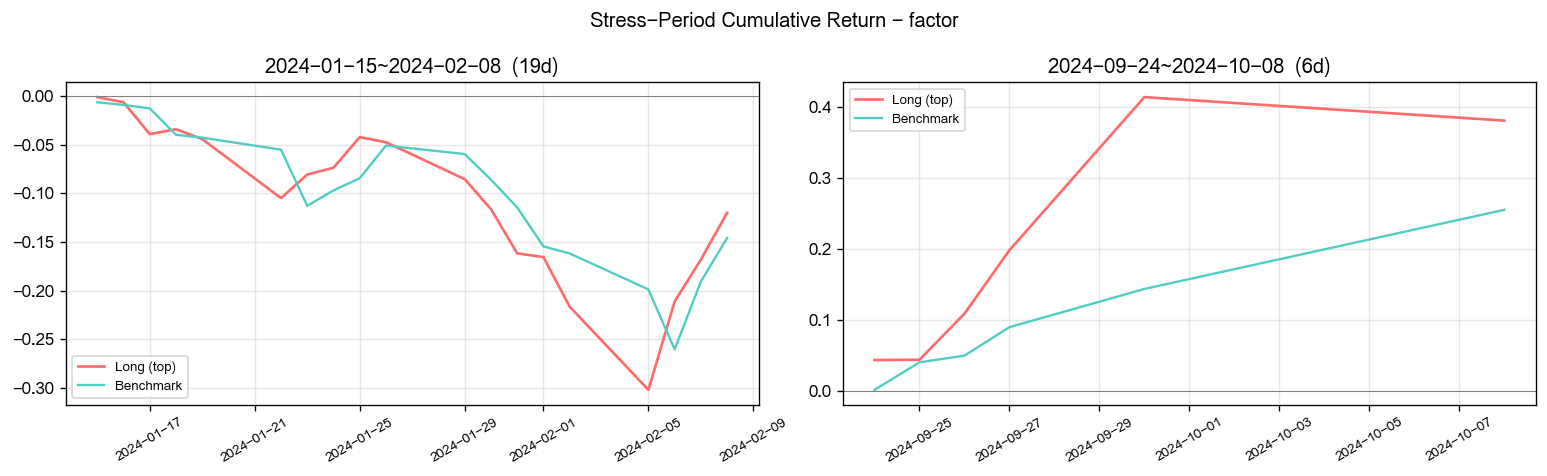

[2026-07-21 19:22:18] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-21 19:22:18] [warning  ] 返回的Outputs实例(size=35323966) 大于 64K, 将不会被缓存
[2026-07-21 19:22:18] [info     ] bigalpha_eval.v4 运行完成 [6.912s].


In [4]:
if __name__ == "__main__":
    from bigmodule import M
    TRAIN_TABLE = "bigalpha_2026_stock_bar1m"
    datasources = {"bar1m": TRAIN_TABLE}
    if not os.path.exists(MODEL_PATH):
        logger.info("未发现模型, 开始 V9 训练")
        train_and_save({"bar1m": TRAIN_TABLE})
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())
    logger.info("开始评估")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)